# Benchmark Models
### Purpose: benchmark segmentation models on a shared dataset and compare quality and speed.


In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

import time
import matplotlib.pyplot as plt
import pandas as pd
import torch
from src.data.annotations import load_json_annotations
from src.data.augmentations import get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.models.zoo import build_model, MODEL_BENCHMARKS
from src.utils.config import Config
from src.utils.helpers import init_notebook, p

config = Config.load(root = root)

init_notebook(config.train.seed)

train_dir = config.paths.train_images
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)




auto_adjust disabled
=== init_notebook ===
Done


#### Load validation entries

In [2]:
val_count = max(8, int(0.1 * len(entries)))
val_entries = entries[:val_count]

val_tf = get_val_augmentations(config.train.image_size)
val_ds = ImageMaskDataset(val_entries, train_dir, transform = val_tf)

p("Validation samples", len(val_ds))


Validation samples: 15


#### Model definitions

In [3]:
p("Models", MODEL_BENCHMARKS)
#config.show()
p("Batch", config.train.batch_size)
p("Epochs", config.train.epochs)
p("Learning Rate", config.train.learning_rate, precision = 9)
p("Image Size", config.train.image_size)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
p("Device", device)


Models: 12 keys
  simple_cnn:
  unet:
  smp_unet:
    encoder_name: resnet34
  smp_fpn:
    encoder_name: resnet34
  smp_linknet:
    encoder_name: resnet34
  smp_deeplabv3:
    encoder_name: resnet34
  smp_deeplabv3plus:
    encoder_name: resnet34
  segformer:
    model_name: nvidia/segformer-b0-finetuned-ade-512-512
  yolov8n:
  yolov8s:
  yolov8m:
  yolov8l:
Batch: 3
Epochs: 10
Learning Rate: 0.000400000
Image Size: 64
Device: mps


#### Benchmarking

In [4]:
rows = []

def _allocated_bytes(dev: torch.device) -> int:
    if dev.type == "cuda":
        return int(torch.cuda.memory_allocated(dev))
    if dev.type == "mps" and hasattr(torch, "mps") and hasattr(torch.mps, "current_allocated_memory"):
        return int(torch.mps.current_allocated_memory())
    return 0


for name, params in MODEL_BENCHMARKS.items():
    p("Testing model", name)

    try:
        model = build_model(name, in_channels=3, out_channels=3, **params).to(device)
    except Exception as e:
        p("Failed to load model", name)
        p("Error", e)
        continue

    model.eval()

    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_time = 0.0

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
    start_mem = _allocated_bytes(device)

    with torch.no_grad():
        for img_t, mask_t in val_ds:
            img_t = img_t.unsqueeze(0).to(device)
            mask_t = mask_t.unsqueeze(0).to(device)

            t0 = time.time()
            pred = model(img_t)
            t1 = time.time()

            total_time += (t1 - t0)

            from src.training.metrics import compute_metrics_multiclass

            m = compute_metrics_multiclass(pred, mask_t, num_classes=3)

            total_iou += m.get("iou", m.get("mean_iou", 0.0))
            total_dice += m.get("dice", 0.0)
            total_acc += m["acc"]

    n = len(val_ds)
    if device.type == "cuda":
        peak_mem = int(torch.cuda.max_memory_allocated(device))
        mem_used = max(0, peak_mem - start_mem)
    else:
        end_mem = _allocated_bytes(device)
        mem_used = max(0, end_mem - start_mem)

    params_num = sum(p.numel() for p in model.parameters())
    # float32 parameter footprint — useful when CUDA/MPS mem stats are 0
    param_mem_bytes = int(params_num * 4)

    rows.append(
        {
            "model": name,
            "params": params_num,
            "avg_iou": total_iou / n,
            "avg_dice": total_dice / n,
            "avg_acc": total_acc / n,
            "avg_time_sec": total_time / n,
            "gpu_mem_bytes": int(mem_used),
            "param_mem_bytes": param_mem_bytes,
        }
    )

df = pd.DataFrame(rows)
df


Testing model: simple_cnn
Testing model: unet
Testing model: smp_unet
Failed to load model: smp_unet
Error: segmentation_models_pytorch is not installed
Testing model: smp_fpn
Failed to load model: smp_fpn
Error: segmentation_models_pytorch is not installed
Testing model: smp_linknet
Failed to load model: smp_linknet
Error: segmentation_models_pytorch is not installed
Testing model: smp_deeplabv3
Failed to load model: smp_deeplabv3
Error: segmentation_models_pytorch is not installed
Testing model: smp_deeplabv3plus
Failed to load model: smp_deeplabv3plus
Error: segmentation_models_pytorch is not installed
Testing model: segformer
Failed to load model: segformer
Error: transformers not installed
Testing model: yolov8n
Testing model: yolov8s
Testing model: yolov8m
Testing model: yolov8l


,model,params,avg_iou,avg_dice,avg_acc,avg_time_sec,gpu_mem_bytes,param_mem_bytes
0,simple_cnn,38211,0.012866,0.0,0.025732,0.052814,131072,152844
1,unet,31043651,0.000000,0.0,0.801351,0.023666,0,124174604
2,yolov8n,1183587,0.041663,0.0,0.489307,0.041486,0,4734348
3,yolov8s,4720323,0.057857,0.0,0.511556,0.006715,0,18881292
4,yolov8m,14653347,0.062727,0.0,0.180664,0.014209,0,58613388
5,yolov8l,32238467,0.071497,0.0,0.204281,0.013159,0,128953868


#### Plot IoU, Speed, Memory

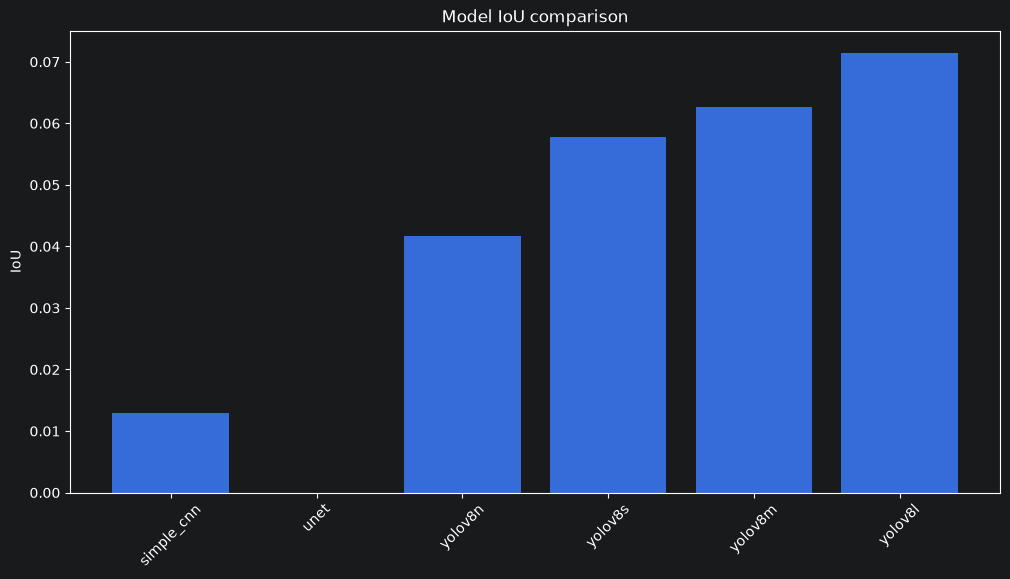

In [5]:
# IoU bar chart
plt.figure(figsize = (12, 6))
plt.bar(df["model"], df["avg_iou"])
plt.xticks(rotation = 45)
plt.ylabel("IoU")
plt.title("Model IoU comparison")
plt.show()


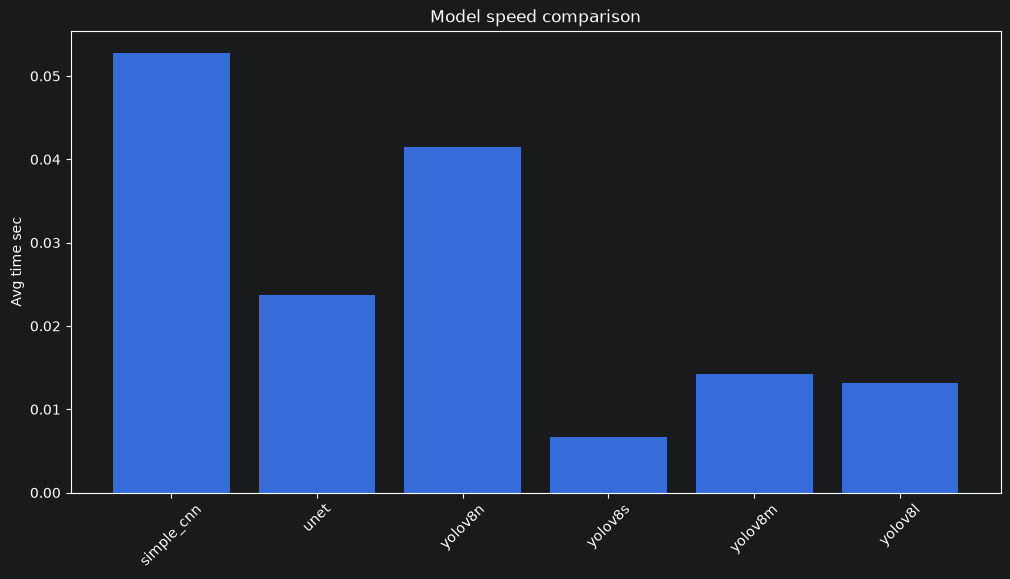

In [6]:
# speed bar chart
plt.figure(figsize = (12, 6))
plt.bar(df["model"], df["avg_time_sec"])
plt.xticks(rotation = 45)
plt.ylabel("Avg time sec")
plt.title("Model speed comparison")
plt.show()


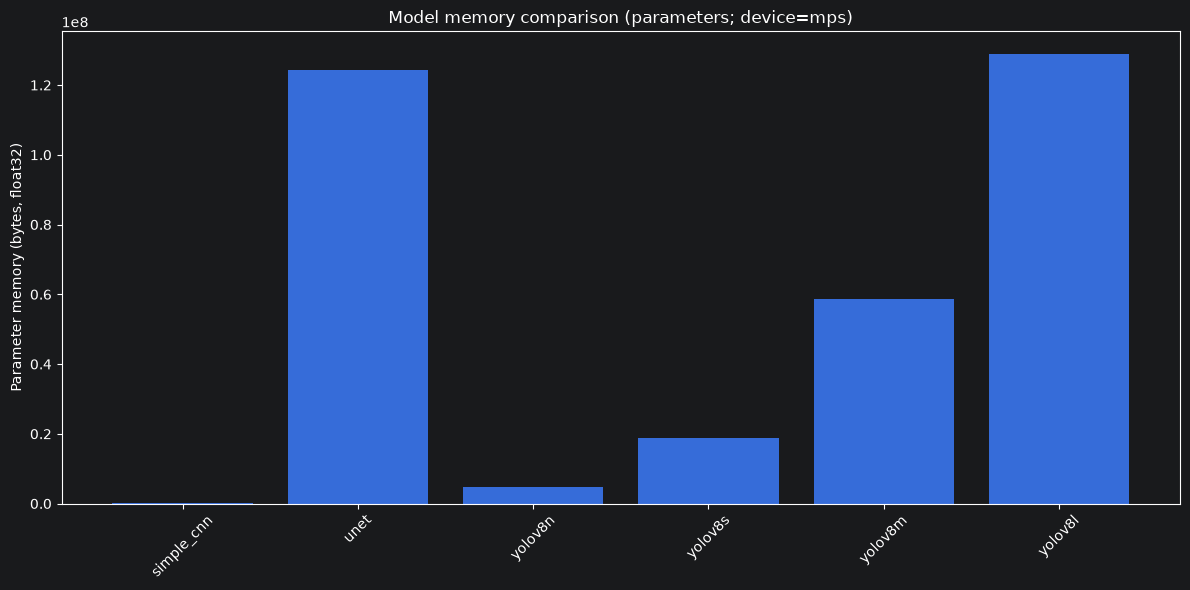

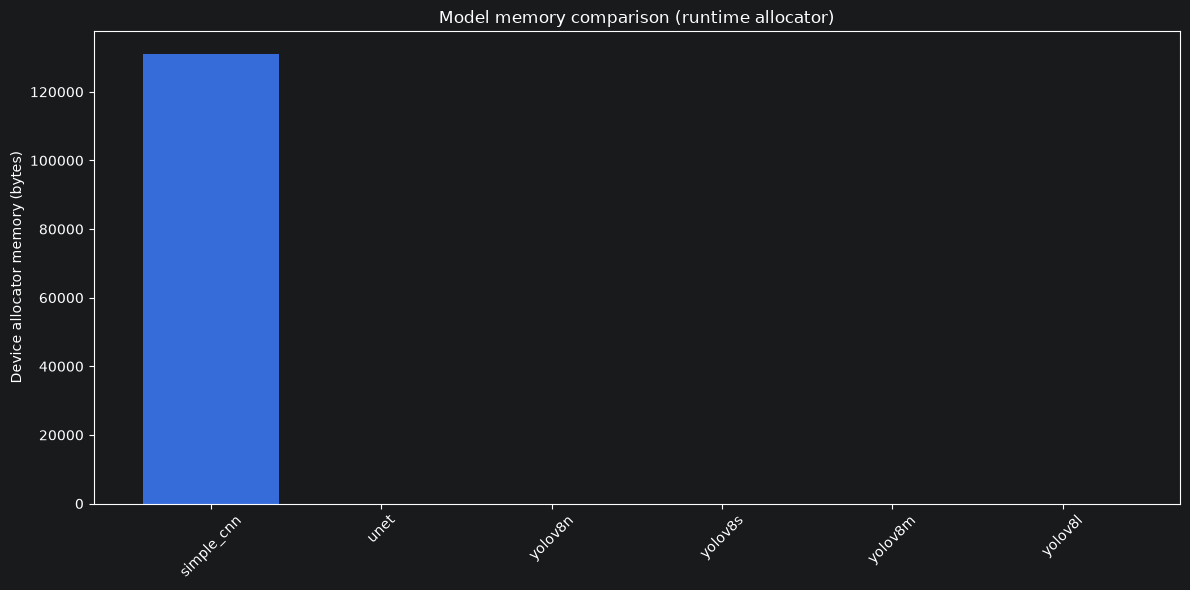

In [7]:
# memory chart — parameter size always; device allocator only when it has real values
from src.utils.helpers import c

if "param_mem_bytes" not in df.columns:
    df["param_mem_bytes"] = df["params"].astype(int) * 4

plt.figure(figsize=(12, 6))
plt.bar(df["model"], df["param_mem_bytes"])
plt.xticks(rotation=45)
plt.ylabel("Parameter memory (bytes, float32)")
plt.title(f"Model memory comparison (parameters; device={device.type})")
plt.tight_layout()
plt.show()

has_device_mem = "gpu_mem_bytes" in df.columns and df["gpu_mem_bytes"].fillna(0).sum() > 0
if has_device_mem:
    plt.figure(figsize=(12, 6))
    plt.bar(df["model"], df["gpu_mem_bytes"])
    plt.xticks(rotation=45)
    plt.ylabel("Device allocator memory (bytes)")
    plt.title("Model memory comparison (runtime allocator)")
    plt.tight_layout()
    plt.show()
else:
    p(
        "Device allocator memory skipped",
        f"all zeros on {device.type} (expected without CUDA) — parameter chart above is the comparison",
        color1=c.ORANGE,
    )


#### Export benchmark results

In [8]:
out_path = config.paths.models / "benchmark_results.csv"
df.to_csv(out_path, index = False)
p("Saved", out_path)


Saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/benchmark_results.csv
